<div style="background-color:#e6f2ff; padding:20px; border-radius:10px;">
<img style="float:left; margin-right:20px;" src='Figures/alinco.png' width="120"/>
<h1 style="color:#000047;">Actividad 2: PipelineTokenizacionNormalizaciónStemmerLematizacion</h1>
<br style="clear:both"/>
</div>

<div style="border-left:4px solid #000047; padding:10px; margin-top:10px; background:#f5f5f5;">
<b>Objetivo:</b> Crear una clase con un pipeline que tokenice, elimine stopwords, aplique stemming y lematizacion, y mida el impacto en el vocabulario.
</div>

<div style="margin-top:10px;">
<b>Instrucciones generales:</b>
<ul>
<li>Crea tu propia clase para preprocesamiento de texto considerando Normalización de texto, Stemming/Lematización y Tokenización para un corpus en inglés y español</li>
<li>Procesa el corpus provisto de 4 textos en inglés y procesa el corpus de noticias en español</li>
<li>Calcula la reduccion de vocabulario en cada etapa</li>
<li>Visualiza los resultados con matplotlib</li>

</ul>
</div>

In [1]:
from nltk.tokenize import word_tokenize, sent_tokenize, TweetTokenizer, MWETokenizer, RegexpTokenizer
from nltk.stem import PorterStemmer, SnowballStemmer, LancasterStemmer, WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.corpus import stopwords
import nltk
import string 
import unicodedata
import re


#Clase para procesar texto
class NLPTextCleaningPipeline:
    def __init__(self, idioma = 'spanish', opciones_normalizar = {"urls","correos","menciones","hashtags","numeros","emojis","puntuacion","espacios"},
                 remover_acentos= True, remover_stopwords= True, 
                 normalizar_unicode=True, metodo_stem = None,
                 expresiones = None                 
                ):
       
        self.idioma = idioma
        self.stopwords = set(stopwords.words('spanish' if idioma=='spanish' else 'english'))

        self.opciones_a_normalizar = opciones_normalizar
        
        self.word_t = word_tokenize
        self.sent_t = sent_tokenize
        self.tweet_t = TweetTokenizer()
        self.MWE_t = MWETokenizer(expresiones or [], separator='_') #(Multi-Word Expression Tokenizer) une palabras para formar una expresión compuesta.
        self.regexp_t = RegexpTokenizer(r'\w+') #(Regular Expression Tokenizer) utiliza expresiones regulares y las separa o extrae los tokens de un texto.

        self.porter = PorterStemmer()
        self.lancaster = LancasterStemmer()
        self.snow_en = SnowballStemmer('english') #Stemming con idioma inglés
        self.snow_es = SnowballStemmer('spanish') #Stemming con idioma español
        
        self.lematizer = WordNetLemmatizer()
 
#=======================================================================================          
    #Función que limpia los textos - corpus 
    def Normalizar(self, texto):
        if self.opciones_a_normalizar is None:
            opciones = {"urls", "correos", "menciones", "hashtags", "numeros", "emojis", "puntuacion", "espacios"}
        if "urls"       in self.opciones_a_normalizar: texto = re.sub(r'https?://\S+', '', texto)
        if "correos"    in self.opciones_a_normalizar: texto = re.sub(r'[\w.]+@[\w.]+\.[a-zA-Z]{2,}', '', texto)
        if "menciones"  in self.opciones_a_normalizar: texto = re.sub(r'@\w+', '', texto)
        if "hashtags"   in self.opciones_a_normalizar: texto = re.sub(r'#\w+', '', texto)
        if "numeros"    in self.opciones_a_normalizar: texto = re.sub(r'\S*\d\S*', '', texto)
        if "emojis"     in self.opciones_a_normalizar: texto = re.sub(r'[^\x00-\x7Fáéíóúüñ¡¿ÁÉÍÓÚÜÑa-zA-Z \n.,!?]', '', texto)
        if "puntuacion" in self.opciones_a_normalizar: texto = re.sub(r'[^\w\sáéíóúüñÁÉÍÓÚÜÑ]', ' ', texto, flags=re.UNICODE)
        if "espacios"   in self.opciones_a_normalizar: texto = re.sub(r'\s+', ' ', texto).strip()
        
        return texto.lower()

#=======================================================================================
    #Función que Elimina tildes y diacríticos usando normalización Unicode.         
    def quitar_acentos(self, texto):      
        nfkd = unicodedata.normalize('NFKD', texto)
        return ''.join(c for c in nfkd if not unicodedata.combining(c))

#=======================================================================================   
    #Función que normaliza texto y quita acentos
    def preprocesar(self, texto):
        texto = self.Normalizar(texto)
        texto = self.quitar_acentos(texto)
        return texto

#=======================================================================================  
    #Función para eliminar los Stopwords
    def eliminar_stopwords(self, tokens):
        return [
            token
            for token in tokens
            if token.lower() not in self.stopwords
        ]

#=======================================================================================        
    #Función para tokenizar texto con LNTK
    def tokenizar(self, texto, metodo = "word"):
            
        if metodo == "word":
            return self.word_t(texto)       
        elif metodo == "sent":
            return self.sent_t(texto)
        elif metodo == "tweet":
            return self.tweet_t.tokenize(texto)
        elif metodo == "regexp":
            return self.regexp_t.tokenize(texto)
        elif metodo == "mwe":
            tokens = self.word_t(texto.lower())
            return self.MWE_t.tokenize(tokens)
        else:
            raise ValueError(f"Método '{metodo}' no válido")
    
#=======================================================================================
    #Función de Stemming con NLTK, obtener la raíz de la palabra    
    def stemming(self, tokens, metodo = "snowball"):
        
        if metodo == "porter":
            return [self.porter.stem(t) for t in tokens]
        elif metodo == "lancaster":
            return [self.lancaster.stem(t) for t in tokens]  
        elif metodo == "snowball":    
            stemmer = (self.snow_es
                if self.idioma == "spanish"
                else self.snow_en)    
            return [stemmer.stem(t) for t in tokens]  
  
        else:
            raise ValueError(f"Método '{metodo}' no válido")            

#=======================================================================================
    #Función para Lematizar con NLTK
    def lematizar(self, tokens):
           
        return [self.lematizer.lemmatize(t) for t in tokens]           

#=======================================================================================    
    #Función para Pipeline principal, etapas:PREPROCESAR (NORMALIZAR Y QUITAR ACENTOS), TOKENIZAR, ELIMINAR STOPWORDS.
    def pipeline(self, texto):   
        texto = self.preprocesar(texto)    
        tokens = self.tokenizar(texto)
        vocabulario_original = len(set(tokens))
        tokens_sin_stop = self.eliminar_stopwords(tokens)    
        return tokens_sin_stop   
        
#=======================================================================================    
    #Función para procesar en el PIPELINE principal; STEMMING Y LEMATIZAR
    def pipeline_vocabulario(self, texto):
        texto = self.preprocesar(texto)
        tokens = self.tokenizar(texto)
        vocabulario_original = len(set(tokens))
        tokens_sin_stop = self.eliminar_stopwords(tokens)
        vocabulario_sin_stop = len(set(tokens_sin_stop))
        stems = self.stemming(tokens_sin_stop)
        vocabulario_stem = len(set(stems))
        lemas = self.lematizar(stems)
        vocabulario_lemma = len(set(lemas))
    
        return {
            "Original": vocabulario_original,
            "Sin Stopwords": vocabulario_sin_stop,
            "Stemming": vocabulario_stem,
            "Lematizacion": vocabulario_lemma
        }


In [2]:
# Lematización con NLTK 
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

In [3]:
#  Corpus de noticias en español
noticias = [
    {"categoria": "tecnología", "texto": "Apple presentó su nuevo chip M4 con IA integrada. La presentación fue en WWDC 2026 #Apple #M4"},
    {"categoria": "tecnología", "texto": "Google lanzó Gemini Ultra, su modelo más poderoso. Supera a GPT-4 en benchmarks https://blog.google.com"},
    {"categoria": "tecnología", "texto": "OpenAI anunció GPT-5 con capacidades multimodales avanzadas @OpenAI"},
    {"categoria": "economía",   "texto": "El peso mexicano se fortalece frente al dólar: $17.50 por USD en mercados internacionales"},
    {"categoria": "economía",   "texto": "La inflación en México cayó al 3.2% en abril 2026, según INEGI #Economia"},
    {"categoria": "economía",   "texto": "Inversión extranjera directa creció 15% en el primer trimestre del año"},
    {"categoria": "ciencia",    "texto": "Científicos descubrieron nueva especie de dinosaurio en Argentina #Paleontología"},
    {"categoria": "ciencia",    "texto": "Investigadores del MIT desarrollaron batería de estado sólido con carga en 5 minutos"},
    {"categoria": "ciencia",    "texto": "La NASA confirmó presencia de agua en la luna sur mediante misión Artemis https://nasa.gov"},
    {"categoria": "salud",      "texto": "Nuevo tratamiento contra el cáncer de páncreas muestra 80% de efectividad en ensayos clínicos"},
    {"categoria": "salud",      "texto": "OMS alerta sobre aumento de casos de resistencia a antibióticos en Latinoamérica #Salud"},
    {"categoria": "salud",      "texto": "Vacuna contra el dengue disponible en farmacias de México a partir de junio 2026"},
]

In [4]:
# Corpus simple en inglés
corpus_en = [
    {'Documento':'text_1','texto':'Natural language processing systems are becoming increasingly sophisticated.'},
    {'Documento':'text_2','texto':'Deep learning models have revolutionized text classification and generation tasks.'},
    {'Documento':'text_3','texto':'Tokenization is the fundamental first step in any NLP preprocessing pipeline.'},
    {'Documento':'text_4','texto':'Researchers are studying computational approaches to human language understanding.'},
]

In [5]:
#Instancio la clase con el idioma español
class_NLP_es = NLPTextCleaningPipeline(idioma='spanish')

In [6]:
#Procesar y Visualizar cada oración de NOTICIAS [original y tokenizada (pipeline)
for noticia in noticias:

    print("Categoría:", noticia["categoria"])
    print("Texto:", noticia["texto"])
    print("PIPELINE:", class_NLP_es.pipeline(noticia["texto"]))
    print("STEMMING:", class_NLP_es.stemming(class_NLP_es.pipeline(noticia["texto"])))
    print("LEMATIZAR:", class_NLP_es.lematizar(class_NLP_es.pipeline(noticia["texto"])))
    print("\n" + "="*100 + "\n") 

Categoría: tecnología
Texto: Apple presentó su nuevo chip M4 con IA integrada. La presentación fue en WWDC 2026 #Apple #M4
PIPELINE: ['apple', 'presento', 'nuevo', 'chip', 'ia', 'integrada', 'presentacion', 'wwdc']
STEMMING: ['apple', 'present', 'nuev', 'chip', 'ia', 'integr', 'present', 'wwdc']
LEMATIZAR: ['apple', 'presento', 'nuevo', 'chip', 'ia', 'integrada', 'presentacion', 'wwdc']


Categoría: tecnología
Texto: Google lanzó Gemini Ultra, su modelo más poderoso. Supera a GPT-4 en benchmarks https://blog.google.com
PIPELINE: ['google', 'lanzo', 'gemini', 'ultra', 'modelo', 'mas', 'poderoso', 'supera', 'benchmarks']
STEMMING: ['googl', 'lanz', 'gemini', 'ultra', 'model', 'mas', 'poder', 'super', 'benchmarks']
LEMATIZAR: ['google', 'lanzo', 'gemini', 'ultra', 'modelo', 'ma', 'poderoso', 'supera', 'benchmark']


Categoría: tecnología
Texto: OpenAI anunció GPT-5 con capacidades multimodales avanzadas @OpenAI
PIPELINE: ['openai', 'anuncio', 'capacidades', 'multimodales', 'avanzadas']
ST

In [17]:
#Calculamos la reduccion de vocabulario en cada etapa en NOTICIAS
texto_es = " ".join(noticia["texto"] for noticia in noticias)
resultado_es = class_NLP_es.pipeline_vocabulario(texto_es)

In [18]:
#Instancio la clase con el idioma inglés
class_NLP_en = NLPTextCleaningPipeline(idioma="english")

In [19]:
#Procesar y Visualizar cada oración de CORPUS_EN  [original y tokenizada (pipeline)
for corpus in corpus_en:

    print("Documento:", corpus["Documento"])
    print("Texto:", corpus["texto"])
    print("PIPELINE:", class_NLP_en.pipeline(corpus["texto"]))
    print("STEMMING:", class_NLP_en.stemming(class_NLP_en.pipeline(corpus["texto"])))
    print("LEMATIZAR:", class_NLP_en.lematizar(class_NLP_en.pipeline(corpus["texto"])))
    print("\n" + "="*100 + "\n") 

Documento: text_1
Texto: Natural language processing systems are becoming increasingly sophisticated.
PIPELINE: ['natural', 'language', 'processing', 'systems', 'becoming', 'increasingly', 'sophisticated']
STEMMING: ['natur', 'languag', 'process', 'system', 'becom', 'increas', 'sophist']
LEMATIZAR: ['natural', 'language', 'processing', 'system', 'becoming', 'increasingly', 'sophisticated']


Documento: text_2
Texto: Deep learning models have revolutionized text classification and generation tasks.
PIPELINE: ['deep', 'learning', 'models', 'revolutionized', 'text', 'classification', 'generation', 'tasks']
STEMMING: ['deep', 'learn', 'model', 'revolution', 'text', 'classif', 'generat', 'task']
LEMATIZAR: ['deep', 'learning', 'model', 'revolutionized', 'text', 'classification', 'generation', 'task']


Documento: text_3
Texto: Tokenization is the fundamental first step in any NLP preprocessing pipeline.
PIPELINE: ['tokenization', 'fundamental', 'first', 'step', 'nlp', 'preprocessing', 'pipe

In [20]:
#Calculamos la reduccion de vocabulario en cada etapa en CORPUS_EN
texto_en = " ".join(doc["texto"] for doc in corpus_en)
resultado_en = class_NLP_en.pipeline_vocabulario(texto_en)

In [21]:
import pandas as pd

In [22]:
#Resultados de los calculos en un DataFrame
df = pd.DataFrame({"Español": resultado_es,"Inglés": resultado_en})
print(df)

               Español  Inglés
Original           100      36
Sin Stopwords       85      28
Stemming            83      28
Lematizacion        85      28


#Se omite el código - celda, por marcar error en el Kernel
"Kernel Restarting
The kernel for Ejercicios_MaestrialA/9. Procesamiento LN/Procesamiento_Natural_del_Lenguaje_2026/Modulo I/Actividad2_PipelineTokenSL_MGRC.ipynb appears to have died. It will restart automatically."

Se actualizo, reinstalo matplotlib NO FUNCIONO

Código
import matplotlib
import matplotlib.pyplot as plt

df_resultados = df.astype(int)
df_resultados.T.plot(kind='bar', figsize=(10,6))

plt.title('Reducción de vocabulario por etapa')
plt.ylabel('Número de palabras únicas')
plt.xlabel('Corpus')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
#Se instalo plotly, como alternativa del matplotlib
#pip install plotly

In [23]:
import plotly.graph_objects as go

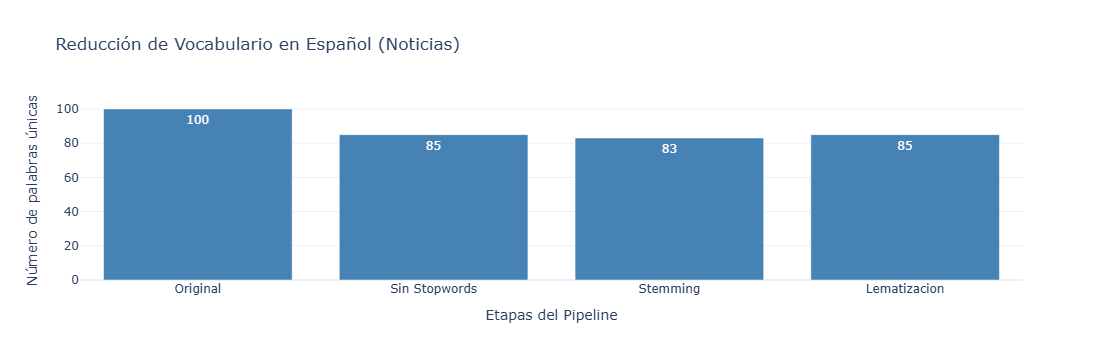

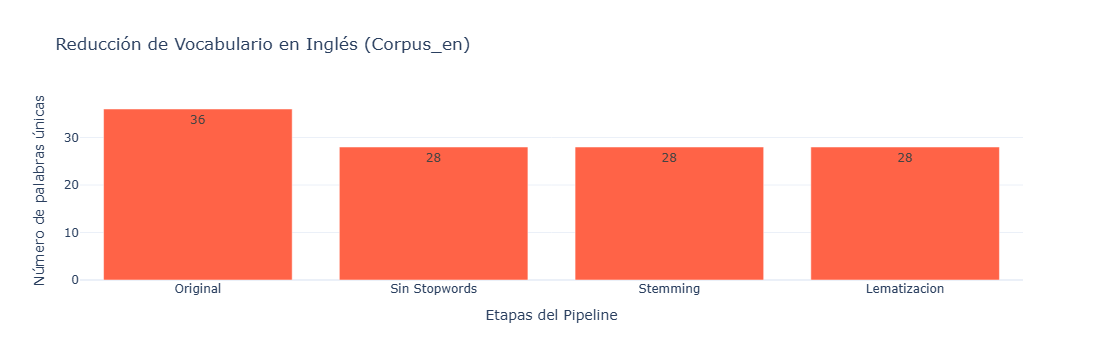

In [24]:
df_numerico = df.astype(int) #mantenemos los datos en numéricos

#Gráfica 1 Palabras en Español
fig_es = go.Figure()
fig_es.add_trace(go.Bar(
    x=df_numerico.index,
    y=df_numerico['Español'],
    marker_color='steelblue',
    text=df_numerico['Español'], 
    textposition='auto',
    hoverinfo='none'
))

fig_es.update_layout(
    title='Reducción de Vocabulario en Español (Noticias)',
    xaxis_title='Etapas del Pipeline',
    yaxis_title='Número de palabras únicas',
    template='plotly_white'
)
fig_es.show()


#Gráfica 2 Palabras en Inglés
fig_en = go.Figure()
fig_en.add_trace(go.Bar(
    x=df_numerico.index,
    y=df_numerico['Inglés'],
    marker_color='tomato',
    text=df_numerico['Inglés'],
    textposition='auto',
    hoverinfo='none'
))

fig_en.update_layout(
    title='Reducción de Vocabulario en Inglés (Corpus_en)',
    xaxis_title='Etapas del Pipeline',
    yaxis_title='Número de palabras únicas',
    template='plotly_white'
)
fig_en.show()